In [82]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

Data Preparation

In [83]:
data=pd.read_csv("car_price_prediction.csv")

In [84]:
data.describe()

,ID,Price,Prod. year,Cylinders,Airbags
count,1.923700e+04,1.923700e+04,19237.000000,19237.000000,19237.000000
mean,4.557654e+07,1.855593e+04,2010.912824,4.582991,6.582627
std,9.365914e+05,1.905813e+05,5.668673,1.199933,4.320168
min,2.074688e+07,1.000000e+00,1939.000000,1.000000,0.000000
25%,4.569837e+07,5.331000e+03,2009.000000,4.000000,4.000000
50%,4.577231e+07,1.317200e+04,2012.000000,4.000000,6.000000
75%,4.580204e+07,2.207500e+04,2015.000000,4.000000,12.000000
max,4.581665e+07,2.630750e+07,2020.000000,16.000000,16.000000


In [85]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

In [86]:
data.shape

(19237, 18)

In [87]:
data.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


Data Preprocessing

In [88]:
data["ID"].is_unique

False

In [89]:
print(data["ID"].duplicated().sum())

313


In [90]:
data.duplicated().sum()

np.int64(313)

In [91]:
data.drop_duplicates(inplace=True)

In [92]:
data.duplicated().sum()

np.int64(0)

In [93]:
data.drop(columns="ID",inplace=True)

In [94]:
data.head()

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [95]:
data["Levy"][data["Levy"]=='-'].count()
# data.loc[("Levy" == "-"), "Levy"].count()
data["Levy"]=data["Levy"].replace(to_replace='-',value=np.nan)

In [96]:
data["Levy"][data["Levy"]=='-'].count()

np.int64(0)

In [97]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             18924 non-null  int64  
 1   Levy              13215 non-null  object 
 2   Manufacturer      18924 non-null  object 
 3   Model             18924 non-null  object 
 4   Prod. year        18924 non-null  int64  
 5   Category          18924 non-null  object 
 6   Leather interior  18924 non-null  object 
 7   Fuel type         18924 non-null  object 
 8   Engine volume     18924 non-null  object 
 9   Mileage           18924 non-null  object 
 10  Cylinders         18924 non-null  float64
 11  Gear box type     18924 non-null  object 
 12  Drive wheels      18924 non-null  object 
 13  Doors             18924 non-null  object 
 14  Wheel             18924 non-null  object 
 15  Color             18924 non-null  object 
 16  Airbags           18924 non-null  int64  
dty

In [98]:
data["Levy"].isna().sum()

np.int64(5709)

In [99]:
data["Levy"]=data["Levy"].astype(dtype="float64")

In [100]:
data["Levy"].describe()

count    13215.000000
mean       906.299205
std        463.296871
min         87.000000
25%        640.000000
50%        781.000000
75%       1058.000000
max      11714.000000
Name: Levy, dtype: float64

In [101]:
data.groupby(["Price"])["Levy"].mean()

Price
1           1202.000000
3            727.714286
6            425.666667
9                   NaN
19                  NaN
               ...     
297930              NaN
308906      1694.000000
627220              NaN
872946      2067.000000
26307500            NaN
Name: Levy, Length: 2315, dtype: float64

<Axes: >

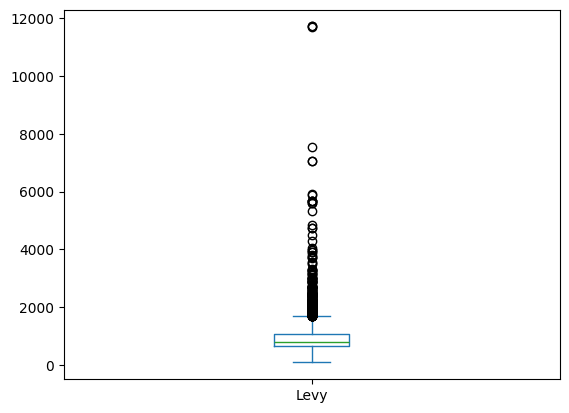

In [102]:
data["Levy"].plot(kind="box")

<Axes: >

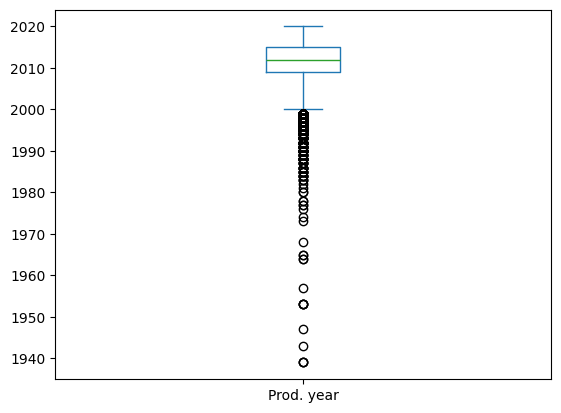

In [103]:
data["Prod. year"].plot(kind="box")

<Axes: >

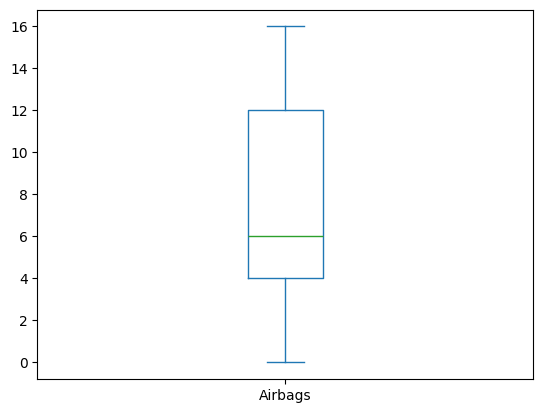

In [104]:
data["Airbags"].plot(kind="box")

In [105]:
q1=data['Levy'].quantile(0.25)
q3=data['Levy'].quantile(0.75)
iqr=q3-q1
upper=q3+(1.5*iqr)
lower=q1-(1.5*iqr)
x=data['Levy'][(data['Levy']>upper) | (data['Levy']<lower)]
y = x.nlargest(20)
d = data.loc[y.index]
print(d)
#OUTliers here are logical

       Price     Levy   Manufacturer                 Model  Prod. year  \
115    11917  11714.0  MERCEDES-BENZ             E 500 AMG        2003   
18984  11917  11714.0  MERCEDES-BENZ                 E 500        2003   
18957  14740  11706.0  MERCEDES-BENZ             E 500 AVG        2005   
17117   7213   7536.0     MITSUBISHI                Pajero        2000   
3994   13172   7063.0         TOYOTA               Alphard        2003   
2159   10349   7058.0         SUBARU                Legacy        2005   
5529    5645   5908.0            BMW                   520        1999   
5367    7840   5877.0  MERCEDES-BENZ               CLK 430        2005   
17767  10349   5681.0     MITSUBISHI                Pajero        1996   
2323    3150   5679.0         TOYOTA                Estima        1997   
14676   7840   5679.0  MERCEDES-BENZ                 C 240        1997   
8160   12544   5666.0         TOYOTA                 Ipsum        2004   
2357   10036   5603.0        HYUNDAI  

In [106]:
data.groupby("Fuel type")["Levy"].median()

Fuel type
CNG               1527.0
Diesel             891.0
Hybrid             640.0
Hydrogen             NaN
LPG                765.0
Petrol             831.0
Plug-in Hybrid     474.0
Name: Levy, dtype: float64

In [107]:
#suppose that levy depends on fuel type
data["Levy"] = data["Levy"].fillna(data.groupby("Fuel type")["Levy"].transform("mean"))

In [108]:
data["Levy"].isnull().sum()

np.int64(1)

In [109]:
data["Levy"] = data["Levy"].fillna(data["Levy"].median())

In [110]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             18924 non-null  int64  
 1   Levy              18924 non-null  float64
 2   Manufacturer      18924 non-null  object 
 3   Model             18924 non-null  object 
 4   Prod. year        18924 non-null  int64  
 5   Category          18924 non-null  object 
 6   Leather interior  18924 non-null  object 
 7   Fuel type         18924 non-null  object 
 8   Engine volume     18924 non-null  object 
 9   Mileage           18924 non-null  object 
 10  Cylinders         18924 non-null  float64
 11  Gear box type     18924 non-null  object 
 12  Drive wheels      18924 non-null  object 
 13  Doors             18924 non-null  object 
 14  Wheel             18924 non-null  object 
 15  Color             18924 non-null  object 
 16  Airbags           18924 non-null  int64  
dty

In [111]:
data["Engine volume"].unique()

array(['3.5', '3', '1.3', '2.5', '2', '1.8', '2.4', '4', '1.6', '3.3',
       '2.0 Turbo', '2.2 Turbo', '4.7', '1.5', '4.4', '3.0 Turbo',
       '1.4 Turbo', '3.6', '2.3', '1.5 Turbo', '1.6 Turbo', '2.2',
       '2.3 Turbo', '1.4', '5.5', '2.8 Turbo', '3.2', '3.8', '4.6', '1.2',
       '5', '1.7', '2.9', '0.5', '1.8 Turbo', '2.4 Turbo', '3.5 Turbo',
       '1.9', '2.7', '4.8', '5.3', '0.4', '2.8', '3.2 Turbo', '1.1',
       '2.1', '0.7', '5.4', '1.3 Turbo', '3.7', '1', '2.5 Turbo', '2.6',
       '1.9 Turbo', '4.4 Turbo', '4.7 Turbo', '0.8', '0.2 Turbo', '5.7',
       '4.8 Turbo', '4.6 Turbo', '6.7', '6.2', '1.2 Turbo', '3.4',
       '1.7 Turbo', '6.3 Turbo', '2.7 Turbo', '4.3', '4.2', '2.9 Turbo',
       '0', '4.0 Turbo', '20', '3.6 Turbo', '0.3', '3.7 Turbo', '5.9',
       '5.5 Turbo', '0.2', '2.1 Turbo', '5.6', '6', '0.7 Turbo',
       '0.6 Turbo', '6.8', '4.5', '0.6', '7.3', '0.1', '1.0 Turbo', '6.3',
       '4.5 Turbo', '0.8 Turbo', '4.2 Turbo', '3.1', '5.0 Turbo', '6.4',
       '3

In [112]:
data["Engine volume"] = data["Engine volume"].str.replace(" Turbo", "", regex=False)

In [113]:
data['Engine volume']=data["Engine volume"].astype("float64")

In [114]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             18924 non-null  int64  
 1   Levy              18924 non-null  float64
 2   Manufacturer      18924 non-null  object 
 3   Model             18924 non-null  object 
 4   Prod. year        18924 non-null  int64  
 5   Category          18924 non-null  object 
 6   Leather interior  18924 non-null  object 
 7   Fuel type         18924 non-null  object 
 8   Engine volume     18924 non-null  float64
 9   Mileage           18924 non-null  object 
 10  Cylinders         18924 non-null  float64
 11  Gear box type     18924 non-null  object 
 12  Drive wheels      18924 non-null  object 
 13  Doors             18924 non-null  object 
 14  Wheel             18924 non-null  object 
 15  Color             18924 non-null  object 
 16  Airbags           18924 non-null  int64  
dty

In [115]:
data["Mileage"].unique()

array(['186005 km', '192000 km', '200000 km', ..., '140607 km',
       '307325 km', '186923 km'], shape=(7687,), dtype=object)

In [116]:
data["Mileage"] = data["Mileage"].str.replace(" km", "", regex=False)
data["Mileage"]=data["Mileage"].astype("float64")

<Axes: >

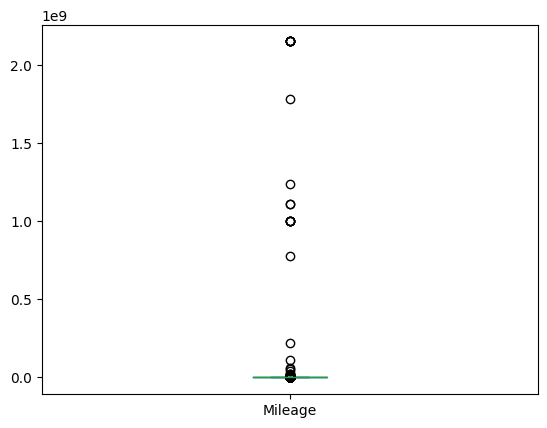

In [117]:
data["Mileage"].plot(kind="box")

In [118]:
q1=data['Mileage'].quantile(0.25)
q3=data['Mileage'].quantile(0.75)
iqr=q3-q1
upper=q3+(1.5*iqr)
lower=q1-(1.5*iqr)
x=data['Mileage'][(data['Mileage']>upper) | (data['Mileage']<lower)]
data["Mileage"][data["Mileage"] > 1000000].count()


np.int64(73)

In [119]:
data.loc[data["Mileage"] > 1000000, "Mileage"] = q3

In [120]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             18924 non-null  int64  
 1   Levy              18924 non-null  float64
 2   Manufacturer      18924 non-null  object 
 3   Model             18924 non-null  object 
 4   Prod. year        18924 non-null  int64  
 5   Category          18924 non-null  object 
 6   Leather interior  18924 non-null  object 
 7   Fuel type         18924 non-null  object 
 8   Engine volume     18924 non-null  float64
 9   Mileage           18924 non-null  float64
 10  Cylinders         18924 non-null  float64
 11  Gear box type     18924 non-null  object 
 12  Drive wheels      18924 non-null  object 
 13  Doors             18924 non-null  object 
 14  Wheel             18924 non-null  object 
 15  Color             18924 non-null  object 
 16  Airbags           18924 non-null  int64  
dty

Category encoding

In [121]:
data["Manufacturer"].unique()

array(['LEXUS', 'CHEVROLET', 'HONDA', 'FORD', 'HYUNDAI', 'TOYOTA',
       'MERCEDES-BENZ', 'OPEL', 'PORSCHE', 'BMW', 'JEEP', 'VOLKSWAGEN',
       'AUDI', 'RENAULT', 'NISSAN', 'SUBARU', 'DAEWOO', 'KIA',
       'MITSUBISHI', 'SSANGYONG', 'MAZDA', 'GMC', 'FIAT', 'INFINITI',
       'ALFA ROMEO', 'SUZUKI', 'ACURA', 'LINCOLN', 'VAZ', 'GAZ',
       'CITROEN', 'LAND ROVER', 'MINI', 'DODGE', 'CHRYSLER', 'JAGUAR',
       'ISUZU', 'SKODA', 'DAIHATSU', 'BUICK', 'TESLA', 'CADILLAC',
       'PEUGEOT', 'BENTLEY', 'VOLVO', 'სხვა', 'HAVAL', 'HUMMER', 'SCION',
       'UAZ', 'MERCURY', 'ZAZ', 'ROVER', 'SEAT', 'LANCIA', 'MOSKVICH',
       'MASERATI', 'FERRARI', 'SAAB', 'LAMBORGHINI', 'ROLLS-ROYCE',
       'PONTIAC', 'SATURN', 'ASTON MARTIN', 'GREATWALL'], dtype=object)

In [122]:
data['Car']=data['Manufacturer']+'_'+data['Model']

In [123]:
data['Car'].nunique()

1601

In [124]:
from category_encoders import TargetEncoder
encoder = TargetEncoder(cols=["Car"])
data["Car"] = encoder.fit_transform(data["Car"], data["Price"])

In [125]:
data['Car'].head()

0    10658.571753
1    13047.967634
2    11102.885135
3     8172.583064
4    11102.885135
Name: Car, dtype: float64

label encoding

In [126]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [127]:
data=data.drop(columns=['Manufacturer','Model'],axis=1)

In [128]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             18924 non-null  int64  
 1   Levy              18924 non-null  float64
 2   Prod. year        18924 non-null  int64  
 3   Category          18924 non-null  object 
 4   Leather interior  18924 non-null  object 
 5   Fuel type         18924 non-null  object 
 6   Engine volume     18924 non-null  float64
 7   Mileage           18924 non-null  float64
 8   Cylinders         18924 non-null  float64
 9   Gear box type     18924 non-null  object 
 10  Drive wheels      18924 non-null  object 
 11  Doors             18924 non-null  object 
 12  Wheel             18924 non-null  object 
 13  Color             18924 non-null  object 
 14  Airbags           18924 non-null  int64  
 15  Car               18924 non-null  float64
dtypes: float64(5), int64(3), object(8)
memory usa

In [129]:
data['Leather interior'].unique()

array(['Yes', 'No'], dtype=object)

In [130]:
data['Leather interior']=le.fit_transform(data['Leather interior'])

In [131]:
data.head()

,Price,Levy,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Car
0,13328,1399.000000,2010,Jeep,1,Hybrid,3.5,186005.0,6.0,Automatic,4x4,04-May,Left wheel,Silver,12,10658.571753
1,16621,1018.000000,2011,Jeep,0,Petrol,3.0,192000.0,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8,13047.967634
2,8467,968.782372,2006,Hatchback,0,Petrol,1.3,200000.0,4.0,Variator,Front,04-May,Right-hand drive,Black,2,11102.885135
3,3607,862.000000,2011,Jeep,1,Hybrid,2.5,168966.0,4.0,Automatic,4x4,04-May,Left wheel,White,0,8172.583064
4,11726,446.000000,2014,Hatchback,1,Petrol,1.3,91901.0,4.0,Automatic,Front,04-May,Left wheel,Silver,4,11102.885135


In [132]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             18924 non-null  int64  
 1   Levy              18924 non-null  float64
 2   Prod. year        18924 non-null  int64  
 3   Category          18924 non-null  object 
 4   Leather interior  18924 non-null  int64  
 5   Fuel type         18924 non-null  object 
 6   Engine volume     18924 non-null  float64
 7   Mileage           18924 non-null  float64
 8   Cylinders         18924 non-null  float64
 9   Gear box type     18924 non-null  object 
 10  Drive wheels      18924 non-null  object 
 11  Doors             18924 non-null  object 
 12  Wheel             18924 non-null  object 
 13  Color             18924 non-null  object 
 14  Airbags           18924 non-null  int64  
 15  Car               18924 non-null  float64
dtypes: float64(5), int64(4), object(7)
memory usa

In [133]:
data["Doors"] = data["Doors"].replace(to_replace="04-May", value="4-5")
data["Doors"] = data["Doors"].replace(to_replace="02-Mar", value="2-3")

In [134]:
data['Doors']=le.fit_transform(data['Doors'])

In [135]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             18924 non-null  int64  
 1   Levy              18924 non-null  float64
 2   Prod. year        18924 non-null  int64  
 3   Category          18924 non-null  object 
 4   Leather interior  18924 non-null  int64  
 5   Fuel type         18924 non-null  object 
 6   Engine volume     18924 non-null  float64
 7   Mileage           18924 non-null  float64
 8   Cylinders         18924 non-null  float64
 9   Gear box type     18924 non-null  object 
 10  Drive wheels      18924 non-null  object 
 11  Doors             18924 non-null  int64  
 12  Wheel             18924 non-null  object 
 13  Color             18924 non-null  object 
 14  Airbags           18924 non-null  int64  
 15  Car               18924 non-null  float64
dtypes: float64(5), int64(5), object(6)
memory usa

In [136]:
data["Wheel"].unique()

array(['Left wheel', 'Right-hand drive'], dtype=object)

In [137]:
data['Wheel']=le.fit_transform(data['Wheel'])

One-Hot encoding

In [138]:
data['Fuel type'].unique()

array(['Hybrid', 'Petrol', 'Diesel', 'CNG', 'Plug-in Hybrid', 'LPG',
       'Hydrogen'], dtype=object)

In [139]:
data['Category'].unique()

array(['Jeep', 'Hatchback', 'Sedan', 'Microbus', 'Goods wagon',
       'Universal', 'Coupe', 'Minivan', 'Cabriolet', 'Limousine',
       'Pickup'], dtype=object)

In [140]:
data["Gear box type"].unique()

array(['Automatic', 'Tiptronic', 'Variator', 'Manual'], dtype=object)

In [141]:
data["Drive wheels"].unique()

array(['4x4', 'Front', 'Rear'], dtype=object)

In [142]:
data["Doors"].unique()

array([1, 0, 2])

In [143]:
data["Color"].unique()

array(['Silver', 'Black', 'White', 'Grey', 'Blue', 'Green', 'Red',
       'Sky blue', 'Orange', 'Yellow', 'Brown', 'Golden', 'Beige',
       'Carnelian red', 'Purple', 'Pink'], dtype=object)

In [144]:
data = pd.get_dummies(data,columns=["Category"])
data = pd.get_dummies(data,columns=["Fuel type"])
data = pd.get_dummies(data,columns=["Gear box type"])
data = pd.get_dummies(data,columns=["Drive wheels"])
data = pd.get_dummies(data,columns=["Color"])

In [145]:
data.head()

,Price,Levy,Prod. year,Leather interior,Engine volume,Mileage,Cylinders,Doors,Wheel,Airbags,...,Color_Green,Color_Grey,Color_Orange,Color_Pink,Color_Purple,Color_Red,Color_Silver,Color_Sky blue,Color_White,Color_Yellow
0,13328,1399.000000,2010,1,3.5,186005.0,6.0,1,0,12,...,False,False,False,False,False,False,True,False,False,False
1,16621,1018.000000,2011,0,3.0,192000.0,6.0,1,0,8,...,False,False,False,False,False,False,False,False,False,False
2,8467,968.782372,2006,0,1.3,200000.0,4.0,1,1,2,...,False,False,False,False,False,False,False,False,False,False
3,3607,862.000000,2011,1,2.5,168966.0,4.0,1,0,0,...,False,False,False,False,False,False,False,False,True,False
4,11726,446.000000,2014,1,1.3,91901.0,4.0,1,0,4,...,False,False,False,False,False,False,True,False,False,False


In [146]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 52 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Price                     18924 non-null  int64  
 1   Levy                      18924 non-null  float64
 2   Prod. year                18924 non-null  int64  
 3   Leather interior          18924 non-null  int64  
 4   Engine volume             18924 non-null  float64
 5   Mileage                   18924 non-null  float64
 6   Cylinders                 18924 non-null  float64
 7   Doors                     18924 non-null  int64  
 8   Wheel                     18924 non-null  int64  
 9   Airbags                   18924 non-null  int64  
 10  Car                       18924 non-null  float64
 11  Category_Cabriolet        18924 non-null  bool   
 12  Category_Coupe            18924 non-null  bool   
 13  Category_Goods wagon      18924 non-null  bool   
 14  Category_Ha

Handling outliers of the target

<Axes: >

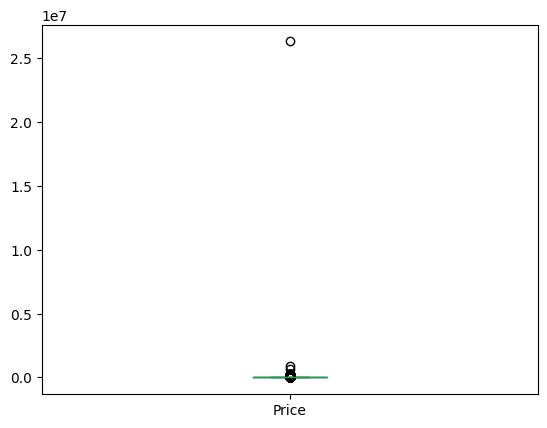

In [147]:
data["Price"].plot(kind="box")

In [148]:
q1=data['Price'].quantile(0.25)
q3=data['Price'].quantile(0.75)
iqr=q3-q1
upper=q3+(1.5*iqr)
lower=q1-(1.5*iqr)
x=data['Price'][(data['Price']>upper) | (data['Price']<lower)]
data["Price"][data["Price"] > 1000000].count()
x=data['Price'][(data['Price']>upper) | (data['Price']<lower)]
x.nlargest(20)

16983    26307500
8541       872946
1225       627220
5008       308906
9367       297930
14839      297930
7749       288521
10759      260296
5840       254024
15283      250574
7283       228935
2283       219527
7353       216391
1145       194438
13328      193184
4722       175622
2768       172486
2912       172486
6468       172486
9248       172486
Name: Price, dtype: int64

In [149]:
x = data[data["Price"] == 26307500]
data.drop(x.index, axis=0, inplace=True)

<Axes: >

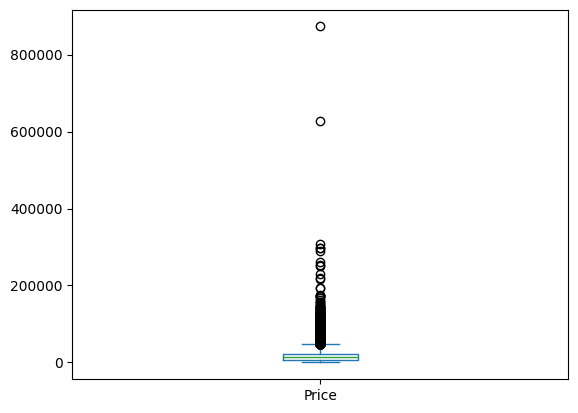

In [150]:
data["Price"].plot(kind="box")

In [151]:
q1=data['Price'].quantile(0.25)
q3=data['Price'].quantile(0.75)
iqr=q3-q1
upper=q3+(1.5*iqr)
lower=q1-(1.5*iqr)
x=data['Price'][(data['Price']>upper) | (data['Price']<lower)]
data["Price"][data["Price"] > 1000000].count()
x=data['Price'][(data['Price']>upper) | (data['Price']<lower)]
x.nlargest(20)

8541     872946
1225     627220
5008     308906
9367     297930
14839    297930
7749     288521
10759    260296
5840     254024
15283    250574
7283     228935
2283     219527
7353     216391
1145     194438
13328    193184
4722     175622
2768     172486
2912     172486
6468     172486
9248     172486
7718     167781
Name: Price, dtype: int64

In [152]:
print(data["Car"][data["Price"] == 872946])

8541    129746.724684
Name: Car, dtype: float64


Trying regression models

In [153]:
from sklearn.model_selection import train_test_split
X=data.drop(columns="Price",axis=1)
y=data["Price"]
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.25,random_state=45,shuffle=True)

In [154]:
from sklearn.linear_model import LinearRegression,SGDRegressor,Lasso,Ridge
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,median_absolute_error 

In [155]:
Models = [
    LinearRegression(),
    SGDRegressor(),
    Lasso(),
    Ridge(),
    RandomForestRegressor(random_state=33),
    GradientBoostingRegressor(random_state=33),
    DecisionTreeRegressor(),
    KNeighborsRegressor()
]

In [156]:
from sklearn.model_selection import cross_val_score
for Model in Models:
    scores = cross_val_score(
        Model,
        X_train,
        y_train,
        cv=5,
        scoring="r2"
    )

    print(f"{Model.__class__.__name__}")
    print("CV r2:", scores)
    print("Mean r2:", scores.mean())
    print("#" * 40)

LinearRegression
CV r2: [0.26547688 0.24660701 0.31827681 0.29855617 0.18243012]
Mean r2: 0.2622693975781415
########################################
SGDRegressor
CV r2: [-3.33617921e+28 -1.56352356e+28 -9.27496568e+29 -1.17455364e+29
 -1.49974899e+29]
Mean r2: -2.4878477173115463e+29
########################################


c:\Users\eng.abo7neka\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.258e+09, tolerance: 4.756e+08
  model = cd_fast.enet_coordinate_descent(
c:\Users\eng.abo7neka\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.168e+12, tolerance: 4.579e+08
  model = cd_fast.enet_coordinate_descent(


Lasso
CV r2: [0.26553401 0.24657357 0.3187095  0.29852543 0.18248651]
Mean r2: 0.2623658039031834
########################################
Ridge
CV r2: [0.26547114 0.24638272 0.3190391  0.29854019 0.1825031 ]
Mean r2: 0.2623872505408936
########################################
RandomForestRegressor
CV r2: [0.6959597  0.8207916  0.77541932 0.75553753 0.67572809]
Mean r2: 0.7446872466306255
########################################
GradientBoostingRegressor
CV r2: [0.63444797 0.70532799 0.62446617 0.62003949 0.68109645]
Mean r2: 0.653075612870232
########################################
DecisionTreeRegressor
CV r2: [0.56367972 0.5973133  0.57069278 0.57246809 0.70566974]
Mean r2: 0.6019647233597729
########################################
KNeighborsRegressor
CV r2: [0.36795259 0.40028746 0.38487381 0.3428101  0.2977426 ]
Mean r2: 0.35873330943540854
########################################


Hyperparameter Tuning

In [161]:
from sklearn.model_selection import GridSearchCV
rf = RandomForestRegressor(random_state=33)

param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [8, 10, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": [0.8]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print(grid_search.best_params_)
print(grid_search.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
{'max_depth': 15, 'max_features': 0.8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
0.7431327473709817


In [159]:
RandomForestRegressorModel=grid_search.best_estimator_
print(f'for Model {str(RandomForestRegressorModel).split("(")[0]}')
RandomForestRegressorModel.fit(X_train, y_train)
print(f'Train Score is : {RandomForestRegressorModel.score(X_train, y_train)}')
print(f'Test Score is : {RandomForestRegressorModel.score(X_test, y_test)}')
y_pred = RandomForestRegressorModel.predict(X_test)
print(f'MAE value is  : {mean_absolute_error(y_test, y_pred)}')
print(f'MSE value is  : {mean_squared_error(y_test, y_pred)}')
print(f'MdSE value is  : {median_absolute_error(y_test, y_pred)}')
print('=================================================')

for Model RandomForestRegressor
Train Score is : 0.9393858473038319
Test Score is : 0.7522659667804559
MAE value is  : 4467.509497155439
MSE value is  : 80376900.24259701
MdSE value is  : 2440.51912641761


In [162]:
result = pd.DataFrame({
    'y_test': y_test,
    'y_pred': y_pred
})
result.sample(20)

,y_test,y_pred
1760,20698,32910.151257
2623,20698,5238.616530
6909,4861,5300.160334
14543,14113,12301.351538
12912,392,1470.018538
2180,750,4201.152113
8428,9722,23131.496631
11330,25,3425.179137
3315,17000,26344.891839
9173,47107,40438.780234


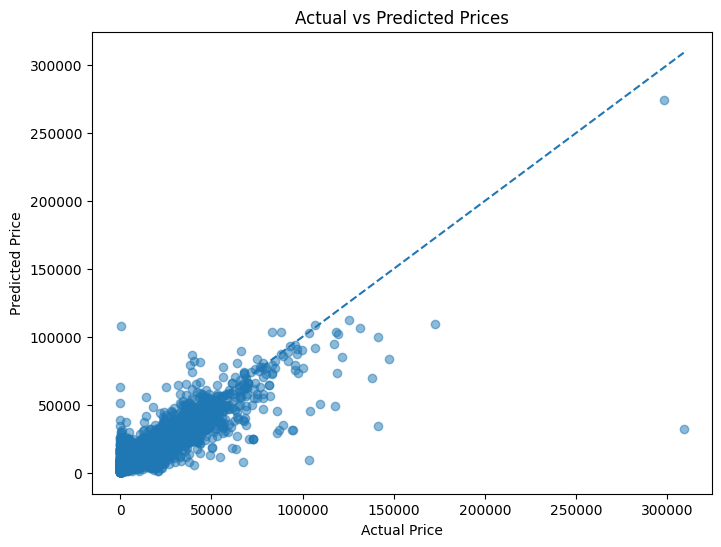

In [164]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.show()